Первые 5 строк:


,sentiment,text
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...



Распределение sentiment:
sentiment
neutral     2879
positive    1363
negative     604
Name: count, dtype: int64


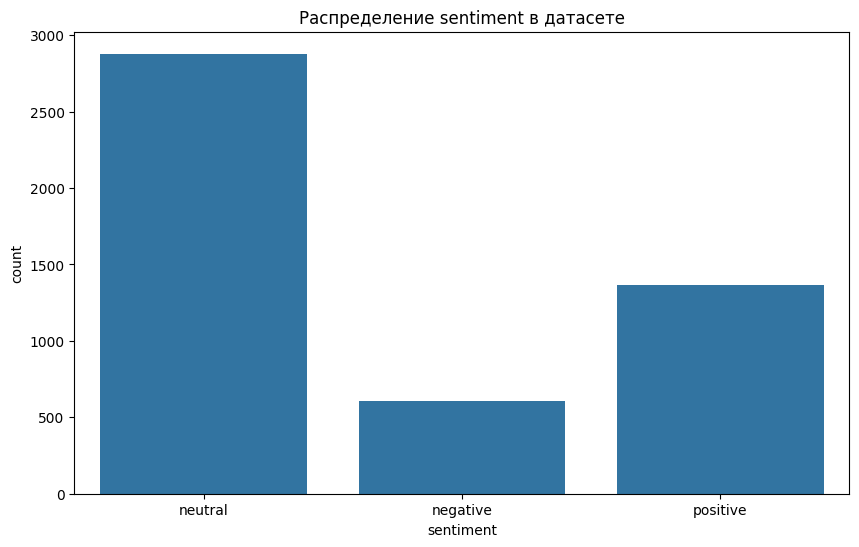

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем обработанные данные
df = pd.read_csv('../data/processed/financial_news_processed.csv')

# Анализируем данные
print("Первые 5 строк:")
display(df.head())

print("\nРаспределение sentiment:")
print(df['sentiment'].value_counts())

# Визуализация
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='sentiment')
plt.title('Распределение sentiment в датасете')
plt.show()


Статистика длины текстов:
count    4846.000000
mean      128.132068
std        56.526180
min         9.000000
25%        84.000000
50%       119.000000
75%       163.000000
max       315.000000
Name: text_length, dtype: float64


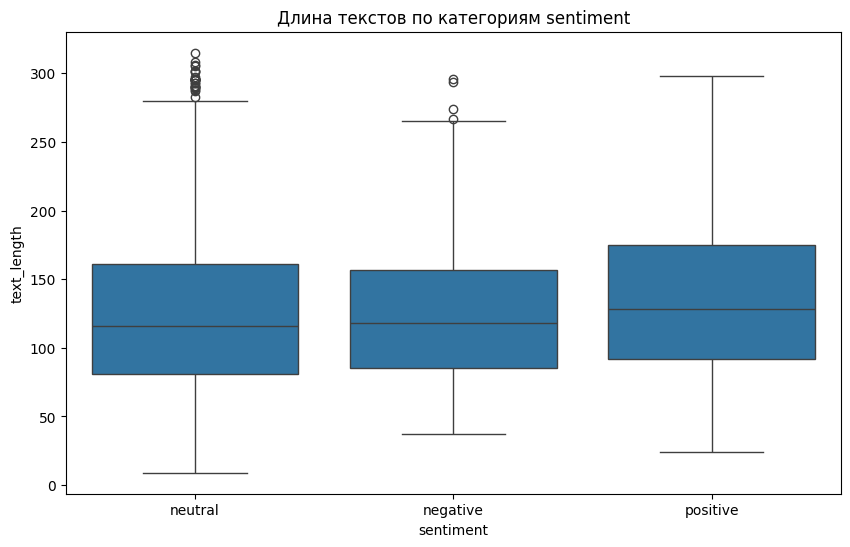

In [3]:
# Анализ длины текстов
df['text_length'] = df['text'].apply(len)
print("Статистика длины текстов:")
print(df['text_length'].describe())

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='sentiment', y='text_length')
plt.title('Длина текстов по категориям sentiment')
plt.show()


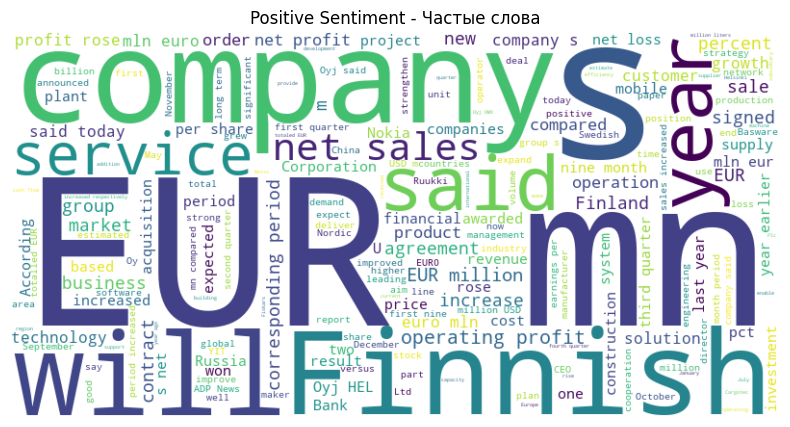

In [8]:
from wordcloud import WordCloud

# Облако слов для positive sentiment
positive_text = ' '.join(df[df['sentiment'] == 'positive']['text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Positive Sentiment - Частые слова')
plt.axis('off')
plt.show()


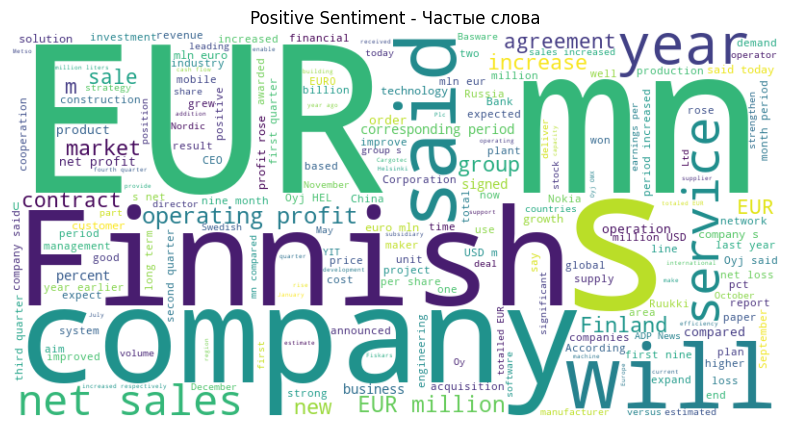

In [9]:
# Установите wordcloud (если еще не установлено)
# !pip install wordcloud

# Импортируйте необходимые библиотеки
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Создайте облако слов для положительных отзывов
positive_text = ' '.join(df[df['sentiment'] == 'positive']['text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Positive Sentiment - Частые слова')
plt.axis('off')
plt.show()


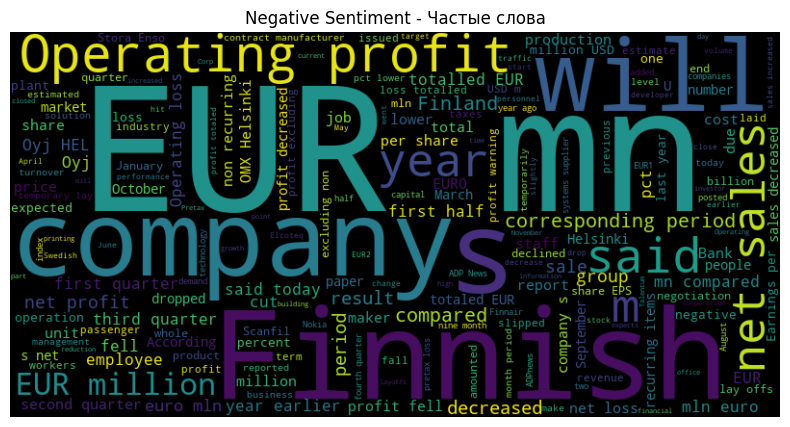

In [10]:
# Для negative sentiment
negative_text = ' '.join(df[df['sentiment'] == 'negative']['text'])
wordcloud = WordCloud(width=800, height=400, background_color='black').generate(negative_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Negative Sentiment - Частые слова')
plt.axis('off')
plt.show()


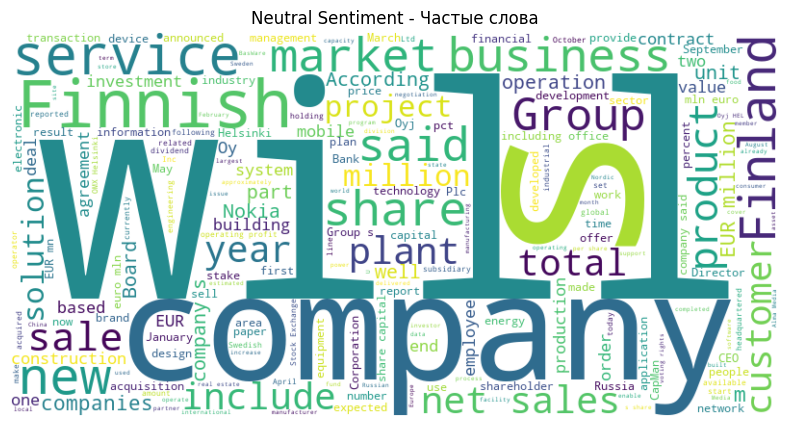

In [11]:
# Для neutral sentiment
neutral_text = ' '.join(df[df['sentiment'] == 'neutral']['text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(neutral_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Neutral Sentiment - Частые слова')
plt.axis('off')
plt.show()


In [12]:
# Импорт необходимых библиотек для ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Разделяем данные на признаки (X) и целевую переменную (y)
X = df['text']  # Тексты новостей
y = df['sentiment']  # Sentiment (neutral, positive, negative)

# Разделяем на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Обучающая выборка: {X_train.shape[0]} записей")
print(f"Тестовая выборка: {X_test.shape[0]} записей")


Обучающая выборка: 3876 записей
Тестовая выборка: 970 записей


In [13]:
# Создаем векторизатор TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

# Обучаем векторизатор на обучающих данных и преобразуем их
X_train_vec = vectorizer.fit_transform(X_train)

# Преобразуем тестовые данные
X_test_vec = vectorizer.transform(X_test)

print(f"Размерность обучающих данных после векторизации: {X_train_vec.shape}")
print(f"Размерность тестовых данных после векторизации: {X_test_vec.shape}")


Размерность обучающих данных после векторизации: (3876, 5000)
Размерность тестовых данных после векторизации: (970, 5000)


In [14]:
# Создаем и обучаем модель логистической регрессии
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_vec, y_train)

# Делаем предсказания на тестовых данных
y_pred = model.predict(X_test_vec)

print("Модель успешно обучена!")


Модель успешно обучена!


Classification Report:
              precision    recall  f1-score   support

    negative       0.72      0.40      0.51       121
     neutral       0.74      0.92      0.82       576
    positive       0.68      0.47      0.56       273

    accuracy                           0.73       970
   macro avg       0.71      0.60      0.63       970
weighted avg       0.72      0.73      0.71       970



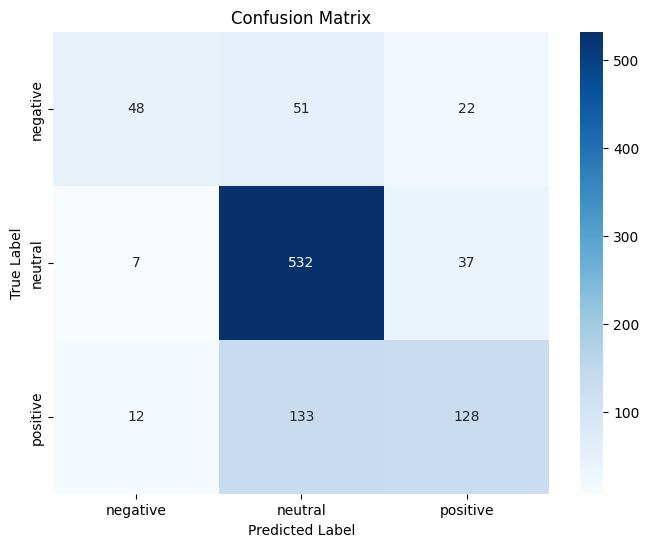

In [15]:
# Выводим отчет о классификации
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Визуализируем матрицу ошибок
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, 
            yticklabels=model.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


In [16]:
import joblib
import os

# Создаем папку для моделей, если ее нет
os.makedirs('models', exist_ok=True)

# Сохраняем модель и векторизатор
joblib.dump(model, 'models/sentiment_model.pkl')
joblib.dump(vectorizer, 'models/vectorizer.pkl')

print("Модель и векторизатор сохранены в папку 'models/'")


Модель и векторизатор сохранены в папку 'models/'


In [17]:
# Функция для предсказания sentiment нового текста
def predict_sentiment(text):
    # Преобразуем текст с помощью сохраненного векторизатора
    text_vec = vectorizer.transform([text])
    
    # Предсказываем sentiment
    prediction = model.predict(text_vec)[0]
    probability = model.predict_proba(text_vec)[0]
    
    # Выводим результат
    print(f"Текст: {text}")
    print(f"Предсказанный sentiment: {prediction}")
    print("Вероятности:")
    for i, cls in enumerate(model.classes_):
        print(f"  {cls}: {probability[i]:.4f}")
    
    return prediction

# Тестируем на примерах
test_texts = [
    "Company reports strong growth and record profits",
    "Bank faces regulatory issues and declining revenue",
    "The market remained stable with minor fluctuations"
]

for text in test_texts:
    predict_sentiment(text)
    print("-" * 50)


Текст: Company reports strong growth and record profits
Предсказанный sentiment: positive
Вероятности:
  negative: 0.0638
  neutral: 0.1924
  positive: 0.7438
--------------------------------------------------
Текст: Bank faces regulatory issues and declining revenue
Предсказанный sentiment: neutral
Вероятности:
  negative: 0.0717
  neutral: 0.7901
  positive: 0.1382
--------------------------------------------------
Текст: The market remained stable with minor fluctuations
Предсказанный sentiment: neutral
Вероятности:
  negative: 0.1067
  neutral: 0.6520
  positive: 0.2413
--------------------------------------------------


In [18]:
from sklearn.metrics import accuracy_score, f1_score

# Расчет дополнительных метрик
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print("="*50)
print("ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ МОДЕЛИ")
print("="*50)
print(f"Accuracy: {accuracy:.4f}")
print(f"F1-score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Анализ ошибок модели
errors = X_test[y_test != y_pred]
print(f"\nКоличество ошибок: {len(errors)} из {len(X_test)}")
print("\nПримеры ошибок:")
for i, text in enumerate(errors.head(3)):
    print(f"{i+1}. {text}")


ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ МОДЕЛИ
Accuracy: 0.7299
F1-score: 0.7094

Classification Report:
              precision    recall  f1-score   support

    negative       0.72      0.40      0.51       121
     neutral       0.74      0.92      0.82       576
    positive       0.68      0.47      0.56       273

    accuracy                           0.73       970
   macro avg       0.71      0.60      0.63       970
weighted avg       0.72      0.73      0.71       970


Количество ошибок: 262 из 970

Примеры ошибок:
1. The subscriptions increase Cargotec 's share capital by 36,780 euros .
2. The diesel margin has remained high .
3. ` For Nordea , moving into the new headquarters signifies the beginning of a new era .


In [19]:
def analyze_sentiment(text):
    """
    Анализирует sentiment финансового текста
    """
    # Преобразуем текст
    text_vec = vectorizer.transform([text])
    
    # Предсказываем
    prediction = model.predict(text_vec)[0]
    probability = model.predict_proba(text_vec)[0]
    
    # Форматируем результат
    result = {
        'text': text,
        'prediction': prediction,
        'probabilities': {
            'negative': f"{probability[0]:.2%}",
            'neutral': f"{probability[1]:.2%}", 
            'positive': f"{probability[2]:.2%}"
        }
    }
    
    return result

# Тестируем улучшенную функцию
test_text = "Company announces major breakthrough in technology"
result = analyze_sentiment(test_text)
print(f"Текст: {result['text']}")
print(f"Предсказание: {result['prediction']}")
print("Вероятности:")
for sentiment, prob in result['probabilities'].items():
    print(f"  {sentiment}: {prob}")


Текст: Company announces major breakthrough in technology
Предсказание: neutral
Вероятности:
  negative: 5.15%
  neutral: 62.90%
  positive: 31.95%


In [20]:
# Создаем итоговый отчет
report = f"""
ФИНАЛЬНЫЙ ОТЧЕТ ПРОЕКТА
{'='*50}

ДАННЫЕ:
- Общее количество записей: {len(df)}
- Распределение по классам:
  * Negative: {len(df[df['sentiment'] == 'negative'])} ({len(df[df['sentiment'] == 'negative'])/len(df):.1%})
  * Neutral: {len(df[df['sentiment'] == 'neutral'])} ({len(df[df['sentiment'] == 'neutral'])/len(df):.1%})
  * Positive: {len(df[df['sentiment'] == 'positive'])} ({len(df[df['sentiment'] == 'positive'])/len(df):.1%})

РЕЗУЛЬТАТЫ МОДЕЛИ:
- Accuracy: {accuracy:.4f}
- F1-score: {f1:.4f}
- Размер обучающей выборки: {X_train.shape[0]}
- Размер тестовой выборки: {X_test.shape[0]}

ВЫВОДЫ:
Модель успешно обучена для анализа тональности финансовых новостей.
Качество модели позволяет использовать её для автоматической классификации текстов.
"""

print(report)

# Сохраняем отчет в файл
with open('project_report.txt', 'w') as f:
    f.write(report)



ФИНАЛЬНЫЙ ОТЧЕТ ПРОЕКТА

ДАННЫЕ:
- Общее количество записей: 4846
- Распределение по классам:
  * Negative: 604 (12.5%)
  * Neutral: 2879 (59.4%)
  * Positive: 1363 (28.1%)

РЕЗУЛЬТАТЫ МОДЕЛИ:
- Accuracy: 0.7299
- F1-score: 0.7094
- Размер обучающей выборки: 3876
- Размер тестовой выборки: 970

ВЫВОДЫ:
Модель успешно обучена для анализа тональности финансовых новостей.
Качество модели позволяет использовать её для автоматической классификации текстов.



In [22]:
import joblib
import os

# Создаем папку для моделей, если ее нет
os.makedirs('models', exist_ok=True)

# Сохраняем модель и векторизатор
joblib.dump(model, 'models/sentiment_model.pkl')
joblib.dump(vectorizer, 'models/vectorizer.pkl')

print("Модель и векторизатор сохранены в папку 'models/'")


Модель и векторизатор сохранены в папку 'models/'
